# Step 3: MSM construction and validation

In [169]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from pca_wrapper import *
from deeptime.decomposition import TICA
from tqdm.notebook import tqdm  # progress bar 
from deeptime.clustering import KMeans

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

from deeptime.util.validation import ck_test
from deeptime.plots import plot_ck_test, Network

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
#### Reloading reduced data

In [2]:
tica_lag = 100 # lag time for TICA in frames, 1000 frames = 200 nanoseconds
tica_dim_distances = 5
tica_dim_dihedrals = 7
pca_dim_distances = 5
pca_dim_dihedrals = 7


tica_dihedrals = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_dihedrals}_dihedrals.npy")
pca_dihedrals = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_dihedrals}_dihedrals.npy")
tica_distances = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_distances}_distances.npy")
pca_distances = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_distances}_distances.npy")


trajectories = [tica_distances, pca_distances, tica_dihedrals, pca_dihedrals]
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]


total_time_micros = 300
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames

Time step (microseconds) 0.00019658711659778472
Time step (nanoseconds) 0.19658711659778472
Time step (picoseconds) 196.58711659778473
One microsecond in frames 5086


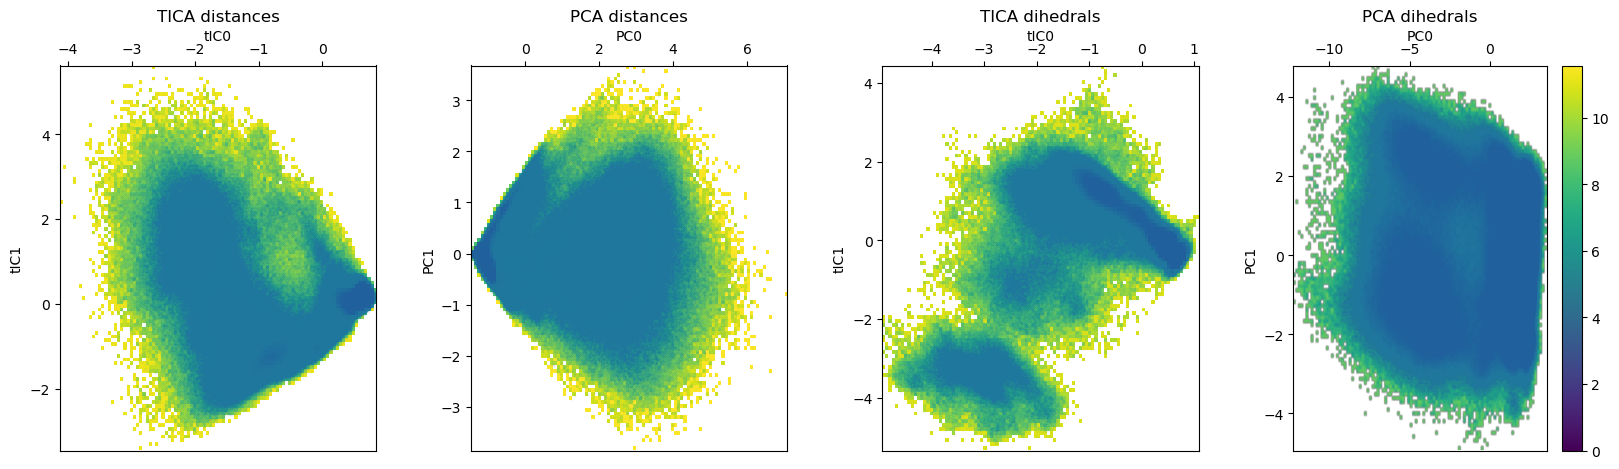

In [8]:
# ---------------------------------------------------------------------------
# First pass: compute all FESs to get global limits for the colorbar
Fs = []

component_x = 0
component_y = 1
for traj in trajectories:
    H, xedges, yedges = np.histogram2d(
        traj[:, component_x],
        traj[:, component_y],
        bins=100,
        density=True
    )
    mask = H > 0
    F = np.full_like(H, np.nan)
    F[mask] = -np.log(H[mask])
    F -= np.nanmin(F)
    Fs.append(F)


vmin = 0
vmax = np.nanmax([np.nanmax(F) for F in Fs])
# ------------------------------------------------------------------------


fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()
pu.plot_free_energy_projection(tica_distances, 0, 1, ax = axes[0], vmin = vmin, vmax=vmax, axlabel = "tIC", axtitle = "TICA distances")
pu.plot_free_energy_projection(pca_distances, 0, 1, ax = axes[1], vmin = vmin, vmax=vmax, axlabel = "PC", axtitle = "PCA distances")
pu.plot_free_energy_projection(tica_dihedrals, 0, 1, ax = axes[2], vmin = vmin, vmax=vmax, axlabel = "tIC", axtitle = "TICA dihedrals")
axes[3], im = pu.plot_free_energy_projection(pca_dihedrals, 0, 1, ax = axes[3], vmin = vmin, vmax=vmax, axlabel = "PC", axtitle = "PCA dihedrals")
plt.colorbar(im, ax=axes[3])
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

---
### performing kmeans clustering + msm transition matrix estimation + implied timescales test

In [ ]:
kcluster_list = [100, 200, 500]

run_kmeans = False # avoid rerunning accidentantly as it takes a long time

if run_kmeans:

    for n_clusters in kcluster_list:
        print(f"Running KMeans with {n_clusters} clusters...")
        kmeans = KMeans(
            n_clusters=n_clusters,
            init_strategy='kmeans++',
            max_iter=100,
            fixed_seed=13,
            n_jobs=8,
            progress=tqdm
        )
        #for i, traj in enumerate(trajectories):
        for i, traj in enumerate([tica_dihedrals]):
            #traj_name = trajectories_labels[i]
            traj_name = "tica_dihedrals"
            kmeans.fit(traj)
            discretized_trajectories = kmeans.transform(traj)
            model = kmeans.fetch_model() # fetches the latest model, containing all important information
            plt.loglog(model.inertias)
            plt.xlabel("iteration")
            plt.ylabel("inertia")
            plt.title("KMeans with uniform initialization inertia during training")

            np.savez(f"../intermediate_outputs/kmeans_plusplus/{n_clusters}clusters_{traj_name}", traj = discretized_trajectories, centers = model.cluster_centers)

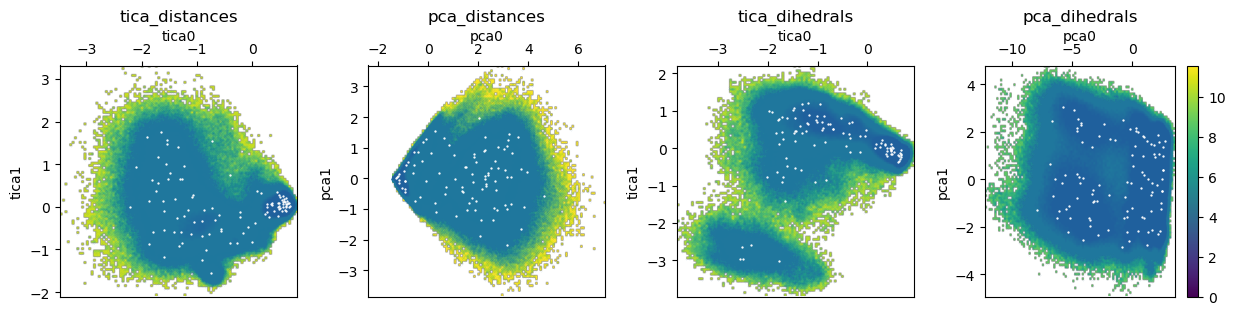

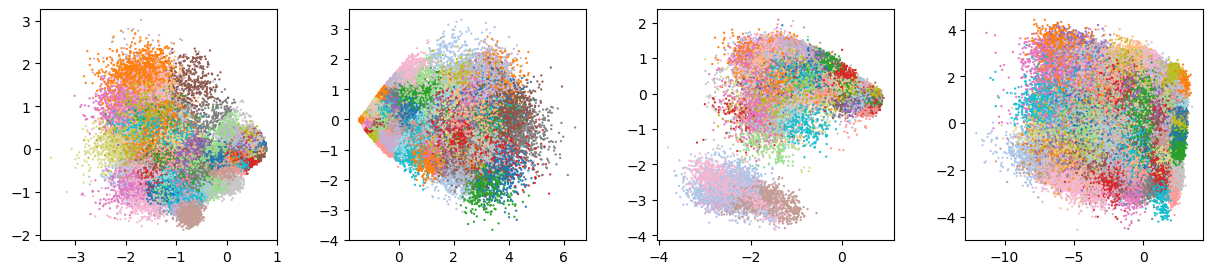

In [13]:
n_clu_for_plot = 100

feature_names = ["distances", "dihedrals"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes = axes.flatten()
for i, (traj_name) in enumerate(trajectories_labels):
        data = np.load(f"../intermediate_outputs/kmeans/{n_clu_for_plot}clusters_{traj_name}.npz")
        centers = data["centers"]
        method = traj_name.split("_")[0]
        dtraj = np.load(f"../intermediate_outputs/dimred/{traj_name}.npy")
        if i == len(trajectories_labels) - 1:
                axes[-1], im = pu.plot_free_energy_projection(dtraj, 0, 1, ax = axes[-1], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")
                plt.colorbar(im, ax=axes[-1])
        else:
                pu.plot_free_energy_projection(dtraj, 0, 1, ax = axes[i], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")
        axes[i].scatter(centers[:, 0], centers[:, 1], s=0.4, alpha=1, color = "white",  label = traj_name)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()


# Plot assignments

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes = axes.flatten()
for i, (traj_name) in enumerate(trajectories_labels):
        data = np.load(f"../intermediate_outputs/kmeans/{n_clu_for_plot}clusters_{traj_name}.npz")
        assignments = data["traj"]
        method = traj_name.split("_")[0]
        dtraj = np.load(f"../intermediate_outputs/dimred/{traj_name}.npy")
        axes[i].scatter(dtraj[:, 0][::10], dtraj[:, 1][::10], c = assignments[::10], cmap = "tab20", s=0.4, alpha=1,  label = traj_name)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()


---

In [15]:
lagtimes = np.arange(10, 200, 10) # lag times in frames (10 frames = 2 nanoseconds, 5000 frames = 1 microsecond)



df = pd.DataFrame(
    index=pd.MultiIndex.from_product(
        [trajectories_labels, kcluster_list, lagtimes],
        names=["Trajectory", "N_clusters", "Lag"]
    ),
    columns=[f"Timescale_{i}" for i in range(1, 11)],
    dtype=float
)

for n_clusters in [100, 200, 500]:
    for traj_name in trajectories_labels:

        data = np.load(f"../intermediate_outputs/kmeans/{n_clusters}clusters_{traj_name}.npz")
        dtraj = data["traj"]
        populated_clusters = np.unique(dtraj)

        for lag in lagtimes:
            tce = TransitionCountEstimator(
                lagtime=lag,
                count_mode="sliding-effective"
            )
            C = tce.fit(dtraj).fetch_model()

            msm = MaximumLikelihoodMSM(reversible = True).fit(C).fetch_model()
            its = msm.timescales(k=10)
            cols = [f"Timescale_{i}" for i in range(1, len(its) + 1)]
            df.loc[(traj_name, n_clusters, lag), cols] = its
            df.to_csv("../intermediate_outputs/implied_timescales.csv", mode = "w", header = True)
            df.head()

Skipping state set [9] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [13] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [18] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [44] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [56] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [61] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [62] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [68] due to error in estimation: Some row and corresponding column of the count matrix C have

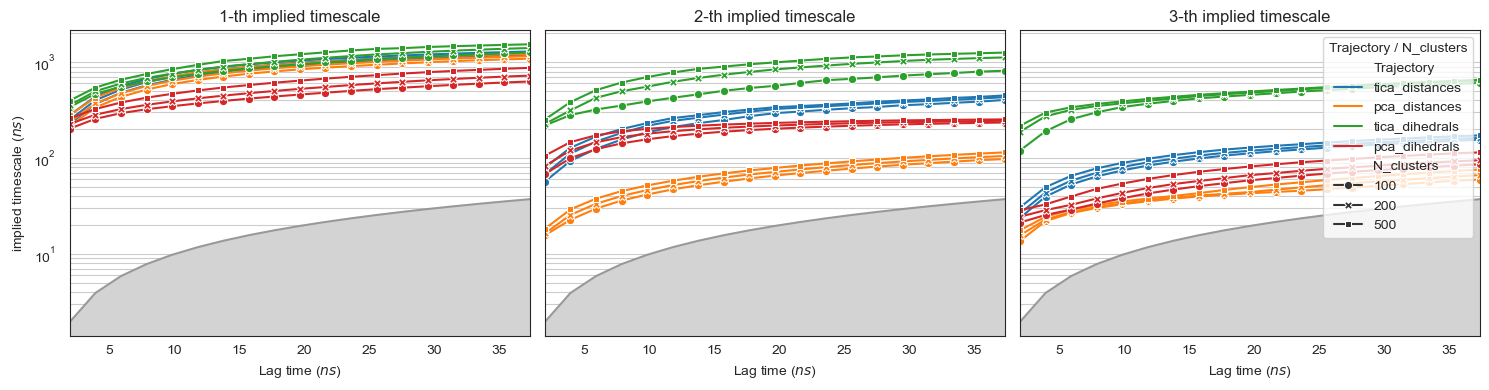

In [ ]:
df = pd.read_csv("../intermediate_outputs/implied_timescales.csv", index_col=[0, 1, 2])
df.index.names = ["Trajectory", "N_clusters", "Lag"]


df = df.reset_index().drop_duplicates(subset=["Trajectory", "N_clusters", "Lag"], keep="last").set_index(["Trajectory", "N_clusters", "Lag"])
df = df.reset_index()

# convert times to nanoseconds
df["Lag"] = df["Lag"].astype(float) * time_step_nanos
for col in df.columns:
    if col.startswith("Timescale_"):
        df[col] = df[col].astype(float) * time_step_nanos



sns.set_style("white")
n_timescales_to_plot = 3

fig, axs = plt.subplots(1, n_timescales_to_plot, figsize=(5*n_timescales_to_plot, 4), sharey=True, sharex=True)


vals = np.sort(df["Lag"].unique())
for ax in axs:
    ax.plot(vals, vals, color = "grey", alpha = 0.7) 
    ax.fill_between(vals, -10, vals, color = "lightgrey", alpha = 1) 
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.tick_params(axis='y', which='minor', length=4)
    ax.tick_params(axis='y', which='major', length=7)
    ax.grid(axis = "y", which = "both", linestyle = "-", linewidth = 0.8)



for i in range(1, n_timescales_to_plot + 1):
    sns.lineplot(data=df, ax = axs[i-1], x="Lag", y=f"Timescale_{i}", hue="Trajectory", style="N_clusters", markers=True, dashes=False)
    axs[i-1].set_xlim(df["Lag"].unique().min(), df["Lag"].unique().max())
    axs[i-1].set_xlabel("Lag time ($ns$)") 
    axs[i-1].set_ylabel(f"implied timescale ($ns$)")
    axs[i-1].set_title(f"{i}-th implied timescale")
    if i != n_timescales_to_plot:
        axs[i-1].get_legend().remove()


axs[n_timescales_to_plot - 1].legend(title="Trajectory / N_clusters", loc = "upper right")
plt.tight_layout()
plt.show()


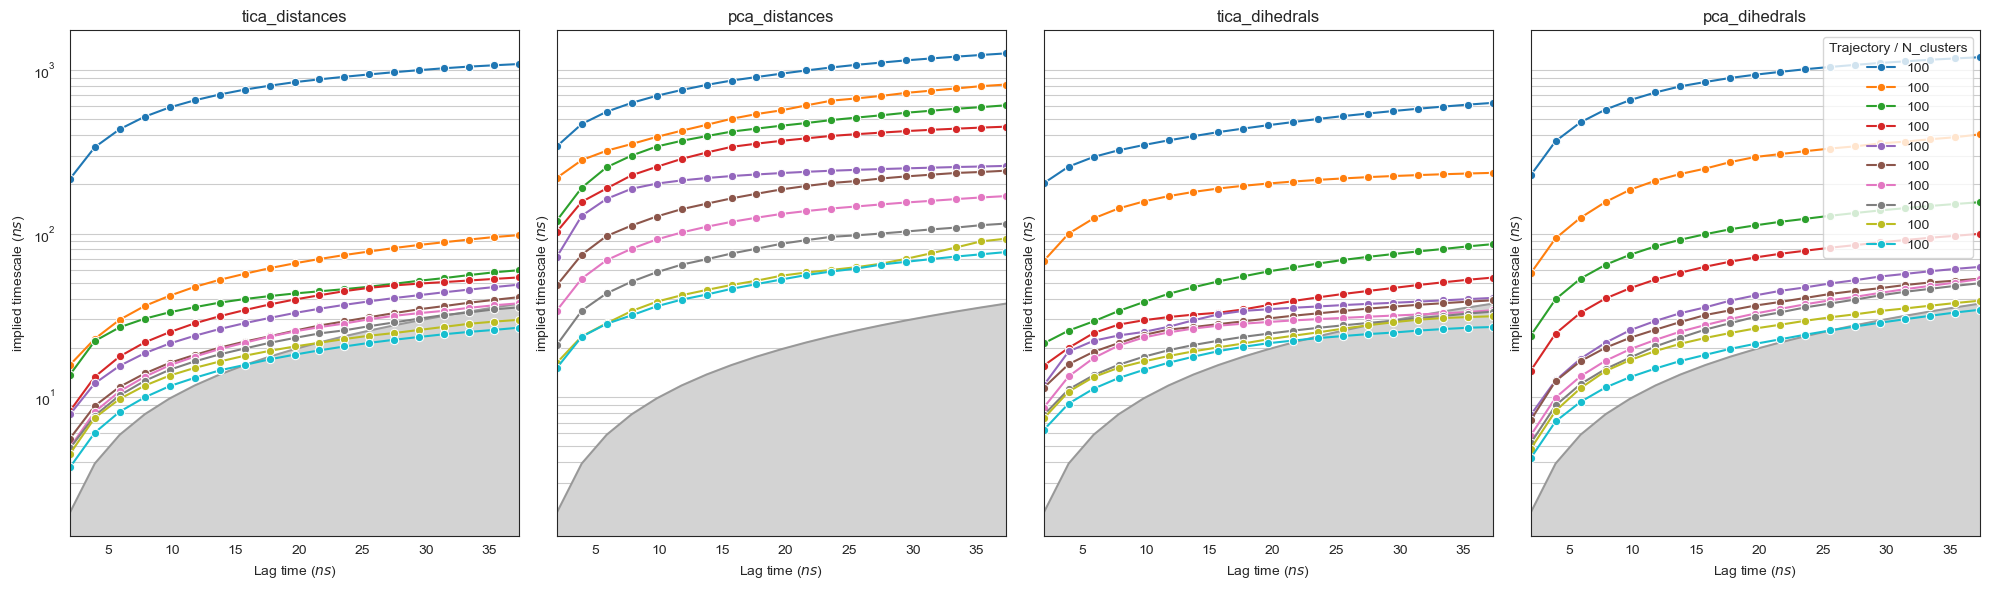

In [84]:
# Plot timescales for trajectories separately

sns.set_style("white")
n_timescales_to_plot = 10
n_clusters_to_plot = 100

fig, axs = plt.subplots(1, 4, figsize=(5*4, 6), sharey=True, sharex=True)


vals = np.sort(df["Lag"].unique())
for ax in axs:
    ax.plot(vals, vals, color = "grey", alpha = 0.7) 
    ax.fill_between(vals, -10, vals, color = "lightgrey", alpha = 1) 
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.tick_params(axis='y', which='minor', length=4)
    ax.tick_params(axis='y', which='major', length=7)
    ax.grid(axis = "y", which = "both", linestyle = "-", linewidth = 0.8)
    ax.set_xlim(df["Lag"].unique().min(), df["Lag"].unique().max())
    ax.set_xlabel("Lag time ($ns$)") 
    ax.set_ylabel(f"implied timescale ($ns$)")


for i, name in enumerate(trajectories_labels):
    temp = df[(df["Trajectory"] == name) & (df["N_clusters"] == n_clusters_to_plot)]
    for scale in range(1, n_timescales_to_plot + 1):
        sns.lineplot(data=temp, ax = axs[i-1], x="Lag", y=f"Timescale_{scale}", style="N_clusters", markers=True, dashes=False)
    if i != n_timescales_to_plot:
        axs[i-1].get_legend().remove()
    axs[i].set_title(f"{name}")


axs[3].legend(title="Trajectory / N_clusters", loc = "upper right")
plt.tight_layout()
plt.show()

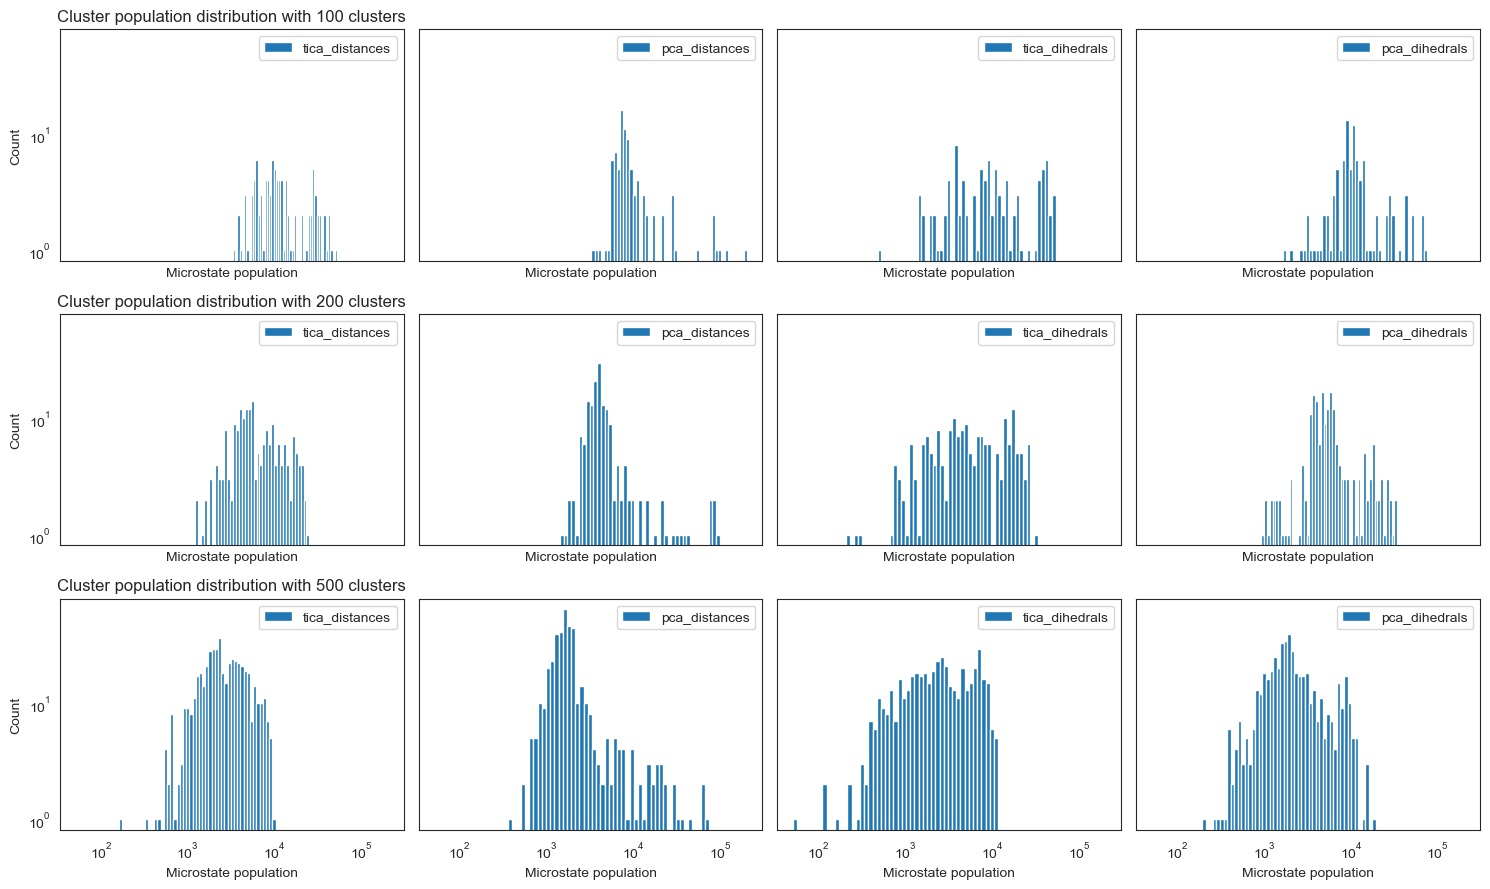

In [30]:
# check cluster populations
fig, axes = plt.subplots(
    len(kcluster_list),
    len(trajectories_labels),
    figsize=(15, 3 * len(kcluster_list)),
    sharex=True,
    sharey=True,
)


for row, n_clusters in enumerate(kcluster_list):
    for col, traj_name in enumerate(trajectories_labels):
        ax = axes[row, col]
        data = np.load(f"../intermediate_outputs/kmeans/{n_clusters}clusters_{traj_name}.npz")
        assignments = data["traj"]
        unique, counts = np.unique(assignments, return_counts=True)
        bins = np.logspace(np.log10(counts.min()),
                np.log10(counts.max()),
                50)

        ax.hist(counts, bins=bins, label=traj_name)
        #axs[i].hist(counts, bins=50, label = traj_name)
        ax.set_xscale("log")
        ax.legend()
        ax.set_yscale("log")
        ax.set_xlabel("Microstate population")
        if col == 0:
                ax.set_ylabel("Count")
                ax.set_title(f"Cluster population distribution with {n_clusters} clusters")

plt.tight_layout()
plt.show()

---
### Estimate MSM at the chosen lagtime $\tau$, and transform cluster-idx trajectories to microstate-idx trajectories

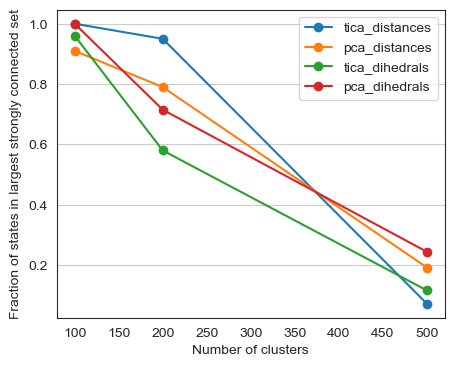

In [85]:
# Inspect largest connected set at varying graph size (number of clusters)

msm_lag = 100 # 20 ns
tce = TransitionCountEstimator(lagtime=msm_lag, count_mode="sliding-effective")

sizes = {}

for n_clusters in kcluster_list:
    for i, name in enumerate(trajectories_labels):
        data = np.load(f"../intermediate_outputs/kmeans/{n_clusters}clusters_{name}.npz")
        dtraj = data["traj"].copy()
        C = tce.fit(dtraj).fetch_model()
        submodel = C.submodel_largest(connectivity_threshold=1., directed=True)
        sizes[name, n_clusters] = submodel.n_states/n_clusters

# plot
fig, ax = plt.subplots(figsize=(5, 4))
for name in trajectories_labels:
    x = [n_clusters for (traj_name, n_clusters) in sizes.keys() if traj_name == name]
    y = [sizes[traj_name, n_clusters] for (traj_name, n_clusters) in sizes.keys() if traj_name == name]
    ax.plot(x, y, marker="o", label=name)


ax.set_xlabel("Number of clusters")
ax.set_ylabel("Fraction of states in largest strongly connected set")
ax.legend()
ax.grid(axis = "y", which = "both", linestyle = "-", linewidth = 0.8)
plt.show()

Number of clusters was chosen as $100$ as this gives the largest connected set with respect to the graph size.

In [102]:
msm_lag = 100 # 20 ns
n_clusters = 100
tce = TransitionCountEstimator(lagtime=msm_lag, count_mode="sliding-effective")

msm_dict = {}
cluster_centers_dict = {} # cluster idx to microstate idx
micro_trajectory_dict = {} # traj -> micro traj
for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans/{n_clusters}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(connectivity_threshold=1., directed=True)

    #cluster_centers_dict[name] = submodel.transform_discrete_trajectories_to_submodel(np.arange(n_clusters))
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{n_clusters}clusters_{msm_lag}lag_{name}_submodel.npy", micro_trajectory_dict[name])
    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

In [103]:
for name, msm in msm_dict.items():
    print("Name: {}, active states: {}".format(name, msm.n_states))

Name: tica_distances, active states: 100
Name: pca_distances, active states: 91
Name: tica_dihedrals, active states: 96
Name: pca_dihedrals, active states: 100


#### Visualization of the stationary distribution $\pi$

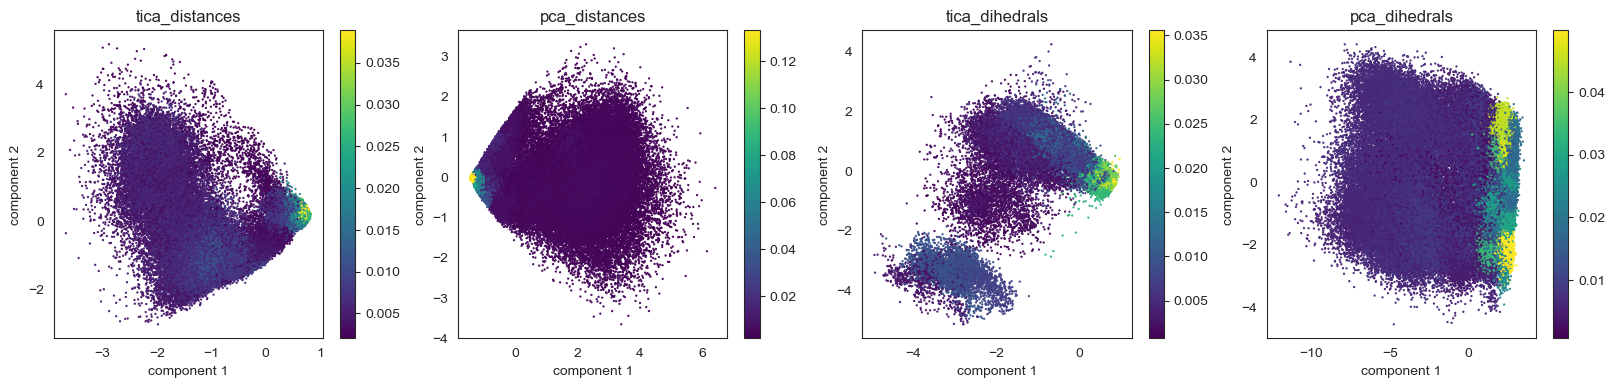

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(20, 4))

for i, name in enumerate(trajectories_labels):

    ax = axs[i]
    traj = micro_trajectory_dict[name]
    pi = msm_dict[name].stationary_distribution

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = pi[traj[mask]]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 1][::10], c = z_values[::10], cmap = "viridis", s=0.4, alpha=1)
    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")
        
plt.show()

---
###  Validation of the microstate model: autocorrelation test (RMSD)

Lets call $\theta (\vec{x})$ an observable of the molecular trajectory.
- Construct the vector of observables $\mathbf{\theta} = (\theta_1, \, \theta_N)$ containing the value of the observable $\theta$ in each markov microstate.


    0. For each cluster center, I take the state closest to the cluster center as the representative state of the markov microstate;
    1. For each representative state, extract its temporal frame index and use it to retrieve the corresponding value of the RMSD from the crystal structure.

- Compute the model predicted autocorrelation according to:

$$
ACF_\theta(k) = \frac{\sum_{i=1}^{N}\, \lambda_i^k\, \langle\mathbf{\theta}, \mathbf{r_i} \rangle^2}{\sum_{i=1}^{N}\, \langle\mathbf{\theta}, \mathbf{r_i}\rangle^2}
$$

where the $\mathbf{r}_i$ are the right eigenvectors of the transition matrix.

- Compare with the empirical autocorrelation.

In [126]:
from scipy.signal import correlate
from deeptime.markov.tools.analysis import correlation


def get_empirical_autocorrelation(obs):
    obs = obs - obs.mean()
    acf = correlate(obs, obs, mode="full")
    acf = acf[acf.size // 2:]      # keep non-negative lags
    acf /= acf[0]                  # normalize so acf[0] = 1
    return acf


def get_msm_autocorrelation(obs, msm, times_array):
    """
    obs: array of observables, one for each microstate
    msm: object of the class deeptime::MarkovStateModelCollection
    """
    # center the observable using the stationary distribution
    obs_mean = np.dot(msm.stationary_distribution, obs)
    obs = obs - obs_mean
    variance = correlation(T = msm.transition_matrix, 
                                obs1 = obs, 
                                obs2=None, 
                                times=(0,), 
                                k=None, 
                                ncv=None)[0]
    
    times_array_in_units_of_tau = np.array(times_array / msm.lagtime, dtype = int)
    acf = correlation(T = msm.transition_matrix, 
                                obs1 = obs, 
                                obs2=None, 
                                times=times_array_in_units_of_tau, 
                                k=None, 
                                ncv=None)
    
    return acf/variance



RMSD_timeseries = np.load("../intermediate_outputs/RMSD_crystal_nm.npy")

theta_dict = {} # one array of observables per each msm model

for i, name in enumerate(trajectories_labels):
    traj = micro_trajectory_dict[name]
    msm = msm_dict[name]
    theta_array = np.ones(msm.n_states)  * (-1)
    for j in np.arange(0, msm.n_states):
        representative_frames = np.where(traj == j)[0]
        RMSD_values = RMSD_timeseries[representative_frames]
        theta_array[j] = np.mean(RMSD_values)
    theta_dict[name] = theta_array


empirical_acf = get_empirical_autocorrelation(RMSD_timeseries)

model_acf_dict = {}
for name in trajectories_labels:
    theta_array = theta_dict[name]
    model_acf_dict[name] = get_msm_autocorrelation(theta_dict[name], msm_dict[name], times_array=np.arange(0, 100000)) 

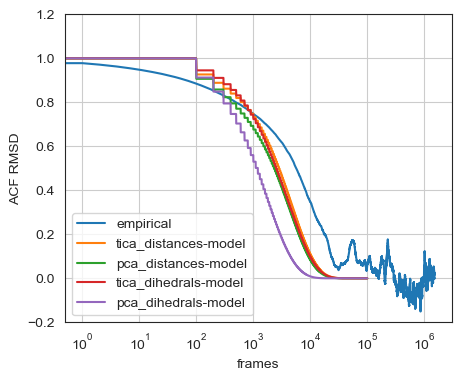

In [127]:
fig, ax = plt.subplots(figsize = (5,4))


ax.plot(np.arange(len(empirical_acf)), empirical_acf, label = "empirical")
for name in trajectories_labels:
    model_acf = model_acf_dict[name]
    ax.plot(np.arange(len(model_acf)), model_acf, label = f"{name}-model")
ax.legend()
ax.set_xscale("log", base = 10)
ax.set_ylabel("ACF RMSD")
ax.set_xlabel("frames")
ax.grid()
plt.ylim(-0.2, 1.2)
plt.show()

Seems quite good, but without error bars what can you say?

TODO:
- look into Bayesian MSMs
- optionally consider bootstrapping.

---
---

# Coarse-graining and validation of the *macrostate* model

[From book, ch 2.5] 

**Choice of the algorithm**

- The standard approach is PCCA+. PCCA (without the +) is excellently explained in the book. 
- authors of HP35 references suggest instead:
    - Starting with the above-defined microstates, MPP first calculates the transition matrix of these states, using a lag time τMPP = 10 ns. (The choice of τMPP is explained in the discussion of Figure 7a below.)
    -  If the self- transition probability of a given state is lower than a certain metastability criterion Qmin ∈ (0, 1), the state will be lumped with the state to which the transition probability is the highest. 
    - This procedure is reiterated, until there are no more transitions for a given Qmin."


Let's start from PCCA+.

#### Choice of the number of macrostates

Markov chain lag: (19.66 nanoseconds -  100 frames)
Threshold for timescales: 98.29 nanoseconds  - (500.00 frames)


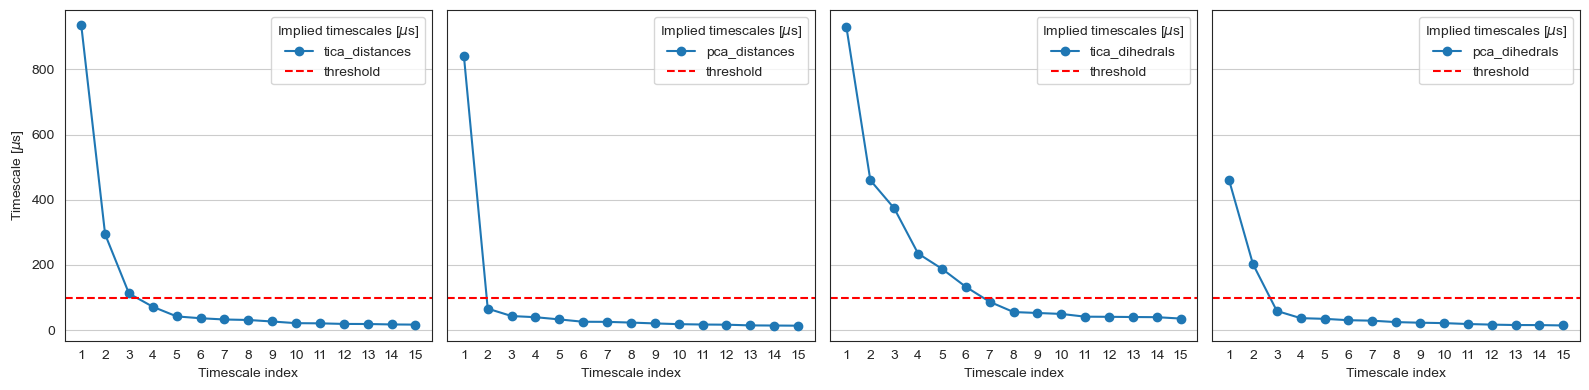

Number of macrostates for PCCA (number oftimescales above threshold, plus 1):
  tica_distances: 4
  pca_distances: 2
  tica_dihedrals: 7
  pca_dihedrals: 3


In [173]:
fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize = (16, 4), sharey=True, sharex=True)
axs = axs.flatten()

################ CHOICE OF THE THRESHOLD FOR TIMESCALES
print(f"Markov chain lag: ({msm_lag * time_step_nanos:.2f} nanoseconds -  {msm_lag} frames)")
threshold_nanos = 5 * msm_lag * time_step_nanos # 5 times the lag time in nanoseconds
print(f"Threshold for timescales: {threshold_nanos:.2f} nanoseconds  - ({int(threshold_nanos / time_step_nanos):.2f} frames)")
n_macrostates_dict = {}

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]
    timescales_ns = msm.timescales(k = 15) * time_step_nanos
    n_macrostates_dict[name] = np.sum(timescales_ns > threshold_nanos) + 1 # n eigenvectors split into n+1 macrostates
    ax = axs[i]

    ax.plot(np.arange(1, len(timescales_ns)+1), timescales_ns, marker = "o", label = f"{name}")
    ax.axhline(y=threshold_nanos, color='red', linestyle='--', label = "threshold")
    ax.set_xticks(np.arange(1, len(timescales_ns)+1))
    ax.set_xlabel("Timescale index")
    ax.set_ylabel("Timescale [$\mu$s]")
    ax.legend(title = fr"Implied timescales [$\mu$s]")
    ax.grid(which = "both", axis = "y", linestyle = "-", linewidth = 0.8)
    if i>0:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()
print("Number of macrostates for PCCA (number oftimescales above threshold, plus 1):")
for name, n_macrostates in n_macrostates_dict.items():
    print(f"  {name}: {n_macrostates}")


In [174]:
from deeptime.markov.tools.analysis import pcca_memberships


def PCCA_assign_microstates(T, n_macro, threshold = 0.):
    """
    Compute nmacro macrostates with PCCA++.
    Assign microstate to the PCCA++ macrostate with highest probability - if there
    exists one of such states with probability > threshold.
    Else, mark as "transition point": index -1
    """
    membership_probs = pcca_memberships(T = T, m = n_macro)
    idxs = np.argmax(membership_probs, axis = 1)
    max_probs = np.max(membership_probs, axis = 1)
    idxs = np.where(max_probs > threshold, idxs, -1)
    return idxs


traj_pcca_assignments_dict = {}
for name in trajectories_labels:
    msm = msm_dict[name]
    n_macro = n_macrostates_dict[name]
    traj = micro_trajectory_dict[name]
    micro_assignments = PCCA_assign_microstates(T = msm.transition_matrix, n_macro = n_macro, threshold = threshold)
    traj_pcca_assignments = np.array([micro_assignments[microstate] if microstate != -1 else -1 for microstate in traj])
    traj_pcca_assignments_dict[name] = traj_pcca_assignments
    np.save(f"../intermediate_outputs/pcca/{n_macro}macro_{name}_assignments.npy", traj_pcca_assignments)

---
#### Macrostate MSM: lagtime choice and CK validation

how to handle the -1 frames? For now I simply assign the closest index in time...

In [175]:
def clean_assignments(dirty_array, max_dist=10000):

    """
    Replace -1 frames with the closest assigned macrostate in time,
    if one exists within max_dist frames. Ties are resolved to the left.
    """
    arr = np.asarray(dirty_array)
    cleaned = arr.copy()
    valid_idx = np.flatnonzero(arr != -1)
    missing_idx = np.flatnonzero(arr == -1)

    if len(valid_idx) == 0:
        return cleaned

    # insertion positions of missing frames among valid frames
    pos = np.searchsorted(valid_idx, missing_idx)
    left_pos = np.clip(pos - 1, 0, len(valid_idx) - 1)
    right_pos = np.clip(pos, 0, len(valid_idx) - 1)
    left_idx = valid_idx[left_pos]
    right_idx = valid_idx[right_pos]
    left_dist = np.abs(missing_idx - left_idx)
    right_dist = np.abs(right_idx - missing_idx)

    # choose left in ties

    use_left = left_dist <= right_dist
    nearest_idx = np.where(use_left, left_idx, right_idx)
    nearest_dist = np.where(use_left, left_dist, right_dist)
    fill_mask = nearest_dist <= max_dist
    cleaned[missing_idx[fill_mask]] = arr[nearest_idx[fill_mask]]
    return cleaned




# merge -1 frames with the closest macrostate in time, if there is one within 10 frames (2 ns)
clean_traj_pcca_assignments = {}
for name in trajectories_labels:
    n_macro = n_macrostates_dict[name]
    traj_pcca_assignments = np.load(f"../intermediate_outputs/pcca/{n_macro}macro_{name}_assignments.npy")
    clean_traj_pcca_assignments[name] = clean_assignments(traj_pcca_assignments)
    if np.any(clean_traj_pcca_assignments[name] == -1):
        print(f"Warning: still have unassigned frames in {name} after cleaning")
    np.save(f"../intermediate_outputs/pcca/{n_macro}macro_{name}_clean_assignments.npy", clean_traj_pcca_assignments[name])

### Build macrostate MSM

probably it doesnt make much sense to repeat the implied timescale test... even with the microstate model it didnt work perfectly, now it would be even worse.

In [ ]:
threshold_frames = int(threshold_nanos / time_step_nanos) # used for macrostate number selection
print(f"Threshold for macrostate number selection: {threshold_frames} frames")

coarse_lag = threshold_frames 


Coarse lag times in frames: [100 107 114 122 129 137 144 151 159 166]


[0 1 2 3 4 5]
(1526041,)


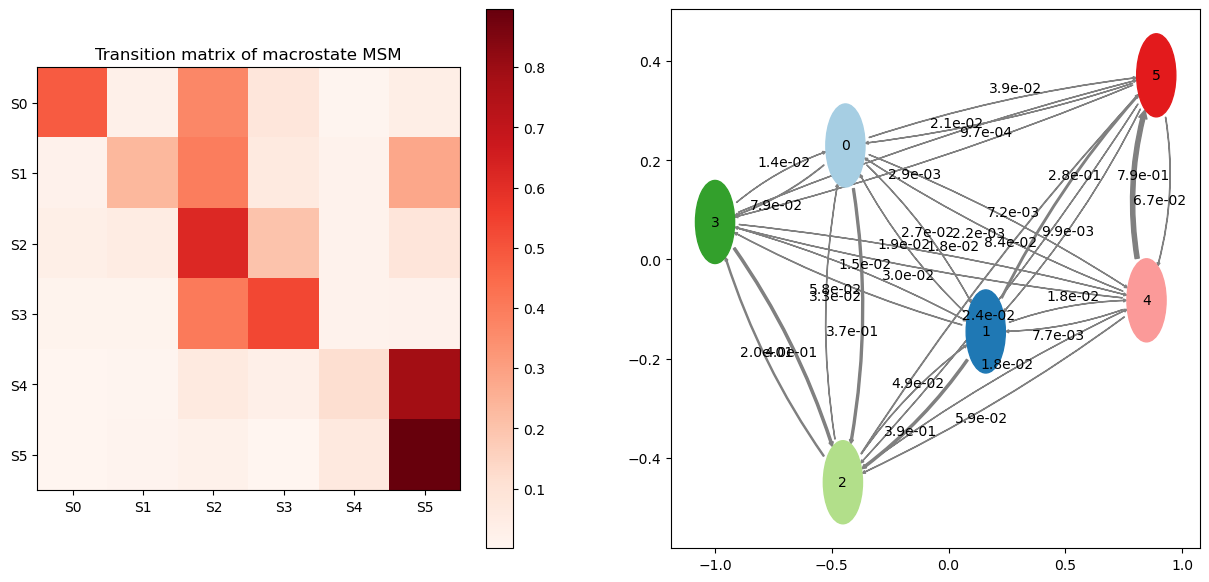

In [ ]:


## First: build a macrostate MSM from the macrostate trajectory
print(np.unique(traj_pcca_assignments))
print(traj_pcca_assignments.shape)

estimator_counts = TransitionCountEstimator(
    lagtime=int(__lag__),
    count_mode="sliding-effective"
)

macro_counts = estimator_counts.fit(traj_pcca_assignments).fetch_model()
# estimate transition matrix
estimator_transition = MaximumLikelihoodMSM(
    reversible=True,
    stationary_distribution_constraint=None
)
macro_msm = estimator_transition.fit(macro_counts).fetch_model()



fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 7))



im = axs[0].imshow(macro_msm.transition_matrix, cmap = "Reds")
fig.colorbar(im, ax = axs[0])
axs[0].set_xticks(np.arange(0, n_macro , 1))
axs[0].set_yticks(np.arange(0, n_macro , 1))
axs[0].set_xticklabels([f"S{i}" for i in range(n_macro)])
axs[0].set_yticklabels([f"S{i}" for i in range(n_macro)])
axs[0].set_title("Transition matrix of macrostate MSM")



G = nx.from_numpy_array(macro_msm.transition_matrix, create_using=nx.DiGraph())
pos = nx.spring_layout(
    G,
    weight="weight",
    k=0.5,
    seed=0
)

nx = Network(
   adjacency_matrix=macro_msm.transition_matrix, 
   state_colors = colors[1:n_macro+1],
   pos = pos
)
nx.plot(ax = axs[1])
plt.show()

### Perform CK test

### Validation of the macrostate model: Chapman-Kolmogorov (= relaxation) test

**Question** how to justify the choice of the number of macrostates? 

from the book, ch 6.4.4:


"
We employed a definition of 50 sets that separate the most slowly convert- ing (“metastable”) parts of state space. *The number of sets can be chosen by fixing a timescale of interest (here 100 ns), then the number of metastable sets are given by the number of implied timescales of the transition matrix slower than that timescale of interest*. The definition of metastable states was obtained by PCCA+.
"



One possibility is build macrostate MSMs at varying number of macrostates and score them with CK test, choosing the model that has better behaviour in the CK test. Also, we can enforce a minimum metastability threshold, to ensure that the macrostates correspond to *metastable* states.



For the moment, I just build macrostate MSM and implement the CK, then I will perform comparative CK.


In [28]:
from deeptime.util.validation import ck_test


def estimate_macro_msm(macro_dtrajs, lag):
    estimator = MaximumLikelihoodMSM(
        lagtime=lag,
        reversible=False,
        allow_disconnected=True
    )
    return estimator.fit(macro_dtrajs).fetch_model()


class TransitionMatrixObservable:
    def __call__(self, model, mlag=1):
        if model is None:
            n = self.n_states
            return np.eye(n)

        T = np.asarray(model.transition_matrix)

        if mlag == 0:
            return np.eye(T.shape[0])

        if not float(mlag).is_integer():
            raise ValueError("mlag must be integer for MSM transition matrices.")

        return np.linalg.matrix_power(T, int(mlag))


# Your macrostate trajectory
# shape: (n_frames,), entries are macrostate labels 0, 1, ..., M-1
macro_dtraj = traj_pcca_assignments
macro_dtrajs = [macro_dtraj]

tau = 1000
multiples = np.arange(1, 100)

models = [
    estimate_macro_msm(macro_dtrajs, lag=tau * k)
    for k in multiples
]

observable = TransitionMatrixObservable()
observable.n_states = n_macro

ck = ck_test(
    models=models,
    observable=observable,
    test_model=models[0],
    err_est = True,
    include_lag0=True
)

[    0  1000  2000  3000  4000  5000  6000  7000  8000  9000 10000 11000
 12000 13000 14000 15000 16000 17000 18000 19000 20000 21000 22000 23000
 24000 25000 26000 27000 28000 29000 30000 31000 32000 33000 34000 35000
 36000 37000 38000 39000 40000 41000 42000 43000 44000 45000 46000 47000
 48000 49000 50000 51000 52000 53000 54000 55000 56000 57000 58000 59000
 60000 61000 62000 63000 64000 65000 66000 67000 68000 69000 70000 71000
 72000 73000 74000 75000 76000 77000 78000 79000 80000 81000 82000 83000
 84000 85000 86000 87000 88000 89000 90000 91000 92000 93000 94000 95000
 96000 97000 98000 99000]
(100, 6, 6)
(100, 6, 6)


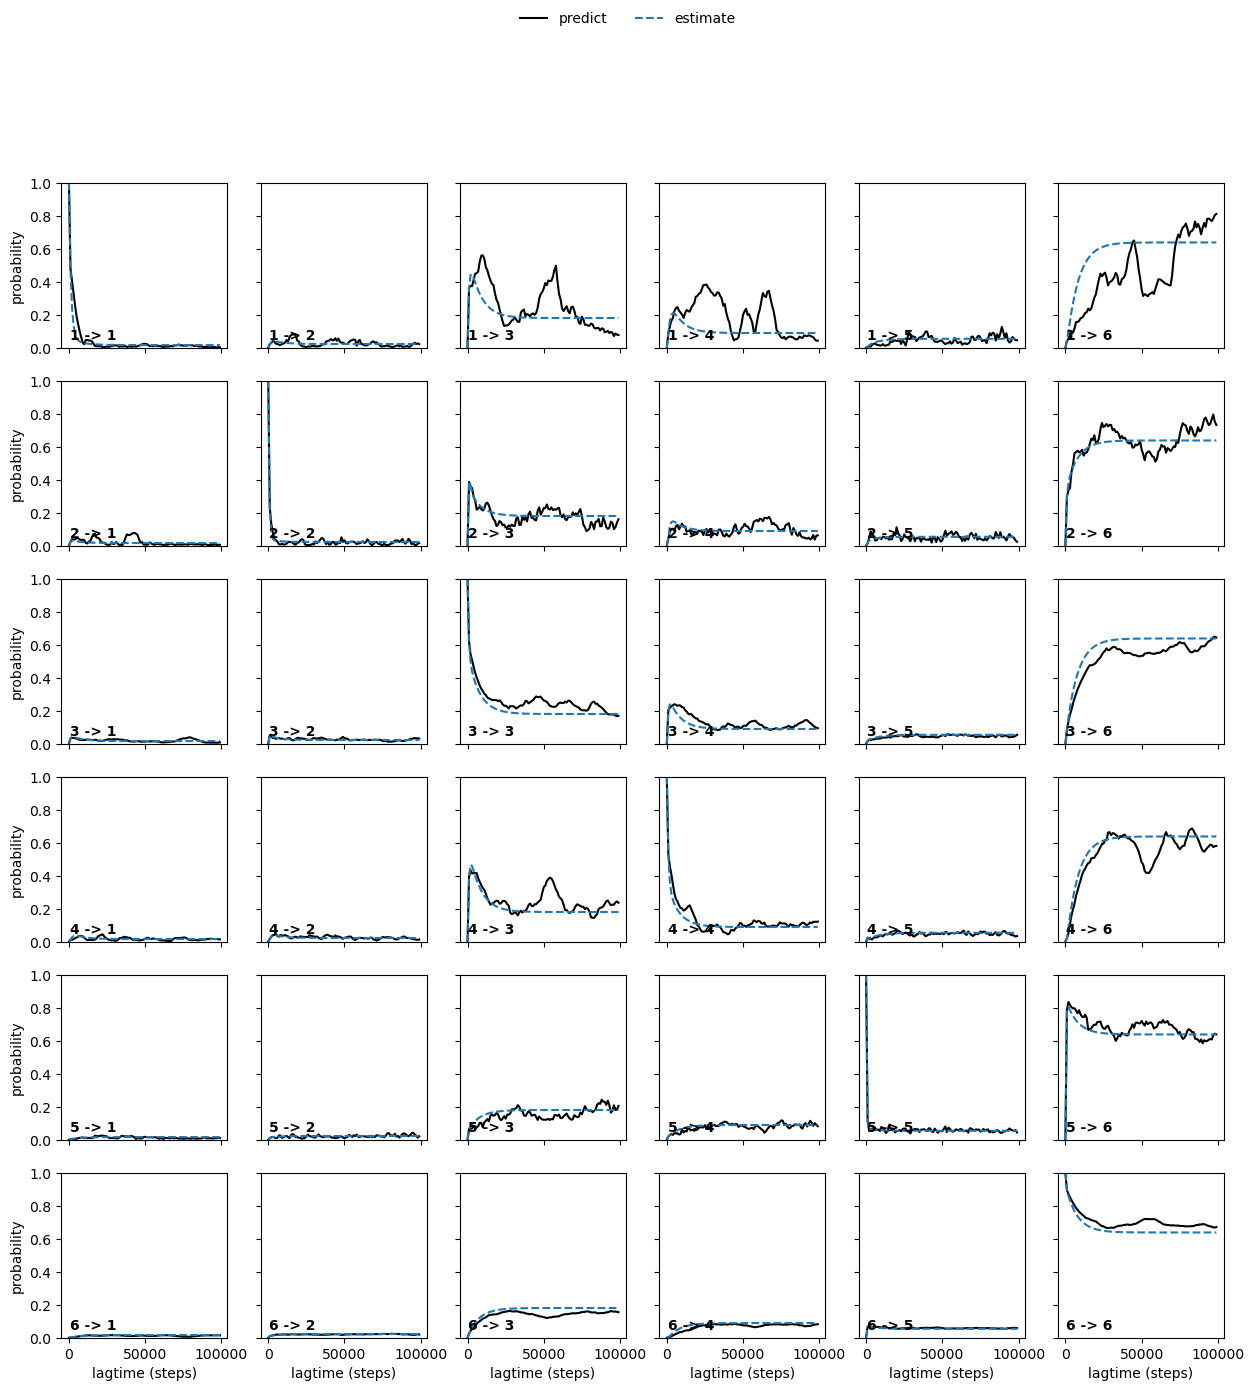

In [29]:
ck.plot()
print(ck.lagtimes)
print(ck.predictions.shape)
print(ck.estimates.shape)

For each row $i$ (starting macrostate) and every lag multiple $k$, compute:

$$
e_i(k) := \sum_{j=1}^{N} | T^{est.}(k \,\tau)_{i,j} - T^{pred.}(k \,\tau)_{i,j} | 
$$


$$
e_i(k) := \sum_{j=1}^{N} | T(k \,\tau)_{i,j} - [T(\tau)]^{k}_{i,j} |
$$


The quantity $e_i(k)$ is **bound** in the range $[0,2]$: 

- it is zero when the two probability distributions are identical
- it is $2$ when they have disjoint support (e.g. one is 1 in a state and one is 1 in a different state, or more complex situations).

This makes it a good quantity for evaluating the CK test.

In [30]:
def evaluate_ck_test(ck):
    #print("Lagtimes:", ck.lagtimes)
    #print("Predictions shape:", ck.predictions.shape)
    #print("Estimates shape:", ck.estimates.shape)

    n_lags = len(ck.lagtimes)
    n_states = ck.predictions.shape[1]

    E = np.zeros((n_lags, n_states))

    for k in range(n_lags):
        
        pred = ck.predictions[k] 
        est = ck.estimates[k]

        for i in range(n_states):
            # row stochastic matrices: columns contain destination states
            # pred[i] and est[i] refer to i as the source state and contain the probabilities of transitioning to each destination state
            E[k, i] = np.sum(np.abs(pred[i] - est[i]))

    # average over source states
    median_l1 = np.median(E, axis=1) 
    p90_l1 = np.percentile(E, 90, axis=1)

    return {
        "e": E,                       # shape (n_lags, n_states)
        "median_l1": median_l1,       # shape (n_lags,)
        "std": np.std(E, axis=1),       # shape (n_lags,)
        "p90_l1": p90_l1,             # shape (n_lags,)
    }   


evaluation_results = evaluate_ck_test(ck)   

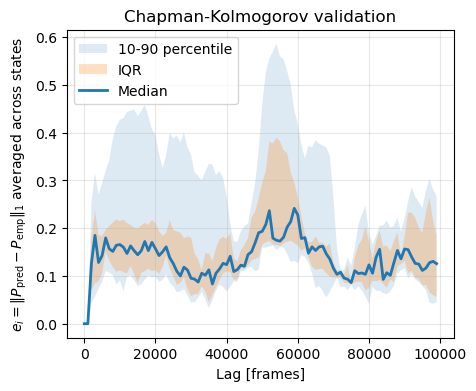

In [31]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(5, 4)
)


E = evaluation_results["e"]

# Quantile bands
q10 = np.percentile(E, 10, axis=1)
q25 = np.percentile(E, 25, axis=1) # IQR interquartile range (25-75)
q75 = np.percentile(E, 75, axis=1)
q90 = np.percentile(E, 90, axis=1)

ax.fill_between(
    ck.lagtimes,
    q10,
    q90,
    alpha=0.15,
    label="10-90 percentile"
)

ax.fill_between(
    ck.lagtimes,
    q25,
    q75,
    alpha=0.25,
    label="IQR"
)

# Summary curves
ax.plot(
    ck.lagtimes,
    evaluation_results["median_l1"],
    lw=2,
    label="Median"
)

ax.set_xlabel("Lag [frames]")
ax.set_ylabel(r"$e_i=\|P_{\rm pred}-P_{\rm emp}\|_1$ averaged across states")
ax.set_title("Chapman-Kolmogorov validation")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

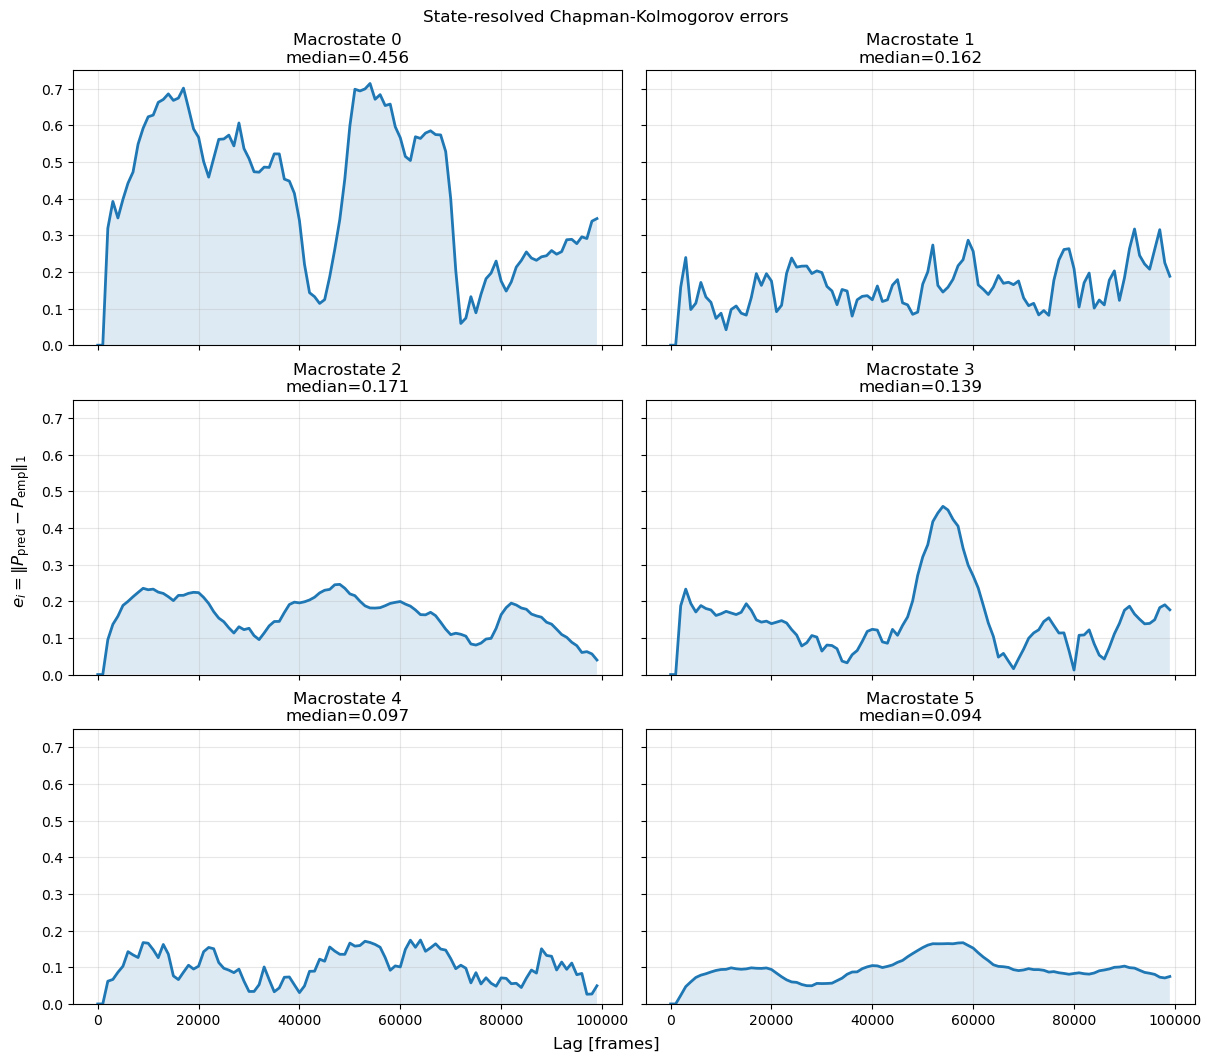

In [32]:
import math

E = evaluation_results["e"]   # (n_lags, n_states)
lags = np.asarray(ck.lagtimes)

n_states = E.shape[1]

ncols = 2
nrows = math.ceil(n_states / ncols)

fig, axs = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6*ncols, 3.5*nrows),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

axs = np.atleast_1d(axs).ravel()

for i in range(n_states):
    ax = axs[i]

    ax.plot(
        lags,
        E[:, i],
        #marker="o",
        lw=2
    )

    ax.fill_between(
        lags,
        0,
        E[:, i],
        alpha=0.15
    )

    ax.set_title(
        f"Macrostate {i}\n"
        f"median={np.median(E[:, i]):.3f}"
    )

    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

for ax in axs[n_states:]:
    ax.axis("off")

fig.supxlabel("Lag [frames]")
fig.supylabel(r"$e_i=\|P_{\rm pred}-P_{\rm emp}\|_1$")
fig.suptitle("State-resolved Chapman-Kolmogorov errors")

plt.show()

#### macrostate-MSM lagtime selection through CK test validation.

#### Visualize macrostates

In [160]:
"""
color_sequence = color_sequences['Paired']

colors = ["grey"] + color_sequence

def assign_color(idx, color_sequence):
    return color_sequence[idx]

micro_colors = [assign_color(idx, color_sequence) for idx in micro_assignments]

################################

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

axs = axs.flatten()
for ax_id, (pca_x, pca_y) in enumerate([(0, 1), (0, 3)]):
    ax = axs[ax_id]
    for i, center in enumerate(centers):
        ax.scatter(center[pca_x], center[pca_y], 
                    marker = "o", 
                    s=40,
                    facecolor = micro_colors[i],
                    edgecolor = "white",
                    linewidth=0.8,
                    zorder=10)

    for id in range(-1, n_macro):
        frames = pca_traj[traj_pcca_assignments == id]
        ax.scatter(
            frames[:, pca_x],
            frames[:, pca_y],
            color=assign_color(id, color_sequence),
            alpha = 0.3,
            s=0.01,
        )
    ax.set_xlabel(f"PC{pca_x}")
    ax.set_ylabel(f"PC{pca_y}")
    #ax.set_title("PCA projection")


ax = axs[2]
bins, counts = np.unique(traj_pcca_assignments, return_counts = True)
ax.bar(bins, counts, color = [assign_color(bin + 1, colors) for bin in bins] )

# custom legend handles
handles = []
for b in bins:
    if b == -1:
        color = colors[0] 
        label = "Unassigned" 
    else:
        label = f"S{b}"
        color = colors[b+1]
    handles.append(
        Patch(facecolor=color, edgecolor="black", label=label)
    )
ax.set_title("Num. simulation frames")
ax.legend(handles=handles)


plt.suptitle(f"PCCA++ (n macrostates = {n_macro}, threshold = {threshold})")
plt.show()
"""

'\ncolor_sequence = color_sequences[\'Paired\']\n\ncolors = ["grey"] + color_sequence\n\ndef assign_color(idx, color_sequence):\n    return color_sequence[idx]\n\nmicro_colors = [assign_color(idx, color_sequence) for idx in micro_assignments]\n\n################################\n\nfig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))\n\naxs = axs.flatten()\nfor ax_id, (pca_x, pca_y) in enumerate([(0, 1), (0, 3)]):\n    ax = axs[ax_id]\n    for i, center in enumerate(centers):\n        ax.scatter(center[pca_x], center[pca_y], \n                    marker = "o", \n                    s=40,\n                    facecolor = micro_colors[i],\n                    edgecolor = "white",\n                    linewidth=0.8,\n                    zorder=10)\n\n    for id in range(-1, n_macro):\n        frames = pca_traj[traj_pcca_assignments == id]\n        ax.scatter(\n            frames[:, pca_x],\n            frames[:, pca_y],\n            color=assign_color(id, color_sequence),\n          